In [15]:
# ==========================================
# Q1. DBSCAN Clustering on Mall Customers
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("/content/sample_data/Mall_Customers_DBSCAN.csv")

# Select the required features
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.30, min_samples=3)
labels = dbscan.fit_predict(X_scaled)

# Number of clusters
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Number of noise points
n_noise = list(labels).count(-1)

print("Number of clusters found:", n_clusters)
print("Number of noise points:", n_noise)

# Add cluster labels to dataframe
df["DBSCAN_Cluster"] = labels

print("\nFirst 10 rows:")
print(df.head(10))

Number of clusters found: 9
Number of noise points: 14

First 10 rows:
   CustomerID  Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    NaN    0                  15                      39   
1           2    NaN    0                  15                      81   
2           3    NaN    0                  16                       6   
3           4    NaN    0                  16                      77   
4           5    NaN    0                  17                      40   
5           6    NaN    0                  17                      76   
6           7    NaN    0                  18                       6   
7           8    NaN    0                  18                      94   
8           9    NaN    0                  19                       3   
9          10    NaN    0                  19                      72   

   DBSCAN_Cluster  
0               0  
1               1  
2               2  
3               1  
4               0  
5    

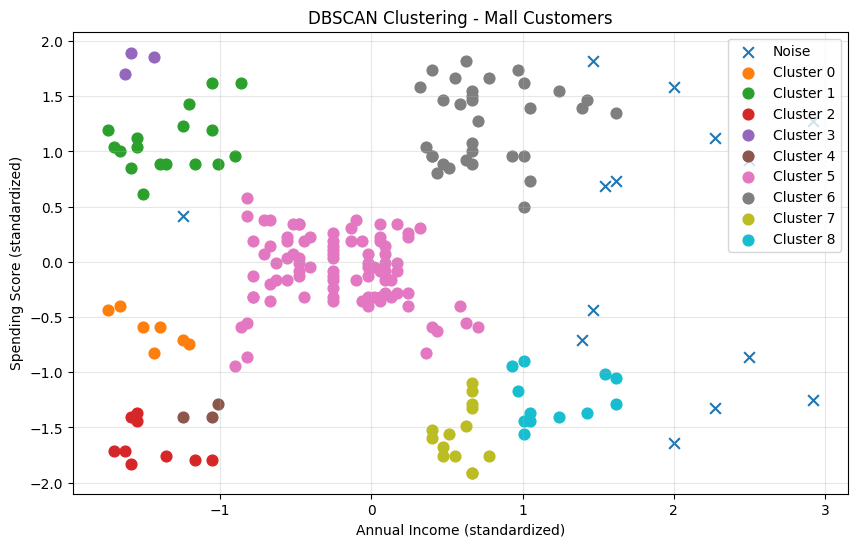

In [16]:
# ==========================================
# Q2. Visualize DBSCAN Results
# ==========================================

plt.figure(figsize=(10, 6))

unique_labels = sorted(set(labels))

for label in unique_labels:

    # Noise points
    if label == -1:
        color = "black"
        marker = "x"
        label_name = "Noise"
    else:
        marker = "o"
        label_name = f"Cluster {label}"

    cluster_points = X_scaled[labels == label]

    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        marker=marker,
        s=60,
        label=label_name
    )

plt.xlabel("Annual Income (standardized)")
plt.ylabel("Spending Score (standardized)")
plt.title("DBSCAN Clustering - Mall Customers")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:

parameters = [
    (0.20, 3),
    (0.25, 3),
    (0.30, 3),
    (0.35, 3),
    (0.40, 3)
]

print("DBSCAN Parameter Comparison")
print("-" * 45)

for eps_value, min_samples_value in parameters:

    model = DBSCAN(
        eps=eps_value,
        min_samples=min_samples_value
    )

    result = model.fit_predict(X_scaled)

    clusters = len(set(result)) - (1 if -1 in result else 0)
    noise = list(result).count(-1)

    print(
        f"eps={eps_value}, "
        f"min_samples={min_samples_value} "
        f"--> Clusters={clusters}, Noise={noise}"
    )

DBSCAN Parameter Comparison
---------------------------------------------
eps=0.2, min_samples=3 --> Clusters=13, Noise=44
eps=0.25, min_samples=3 --> Clusters=12, Noise=16
eps=0.3, min_samples=3 --> Clusters=9, Noise=14
eps=0.35, min_samples=3 --> Clusters=7, Noise=11
eps=0.4, min_samples=3 --> Clusters=4, Noise=10


DBSCAN
Number of clusters: 9
Number of noise points: 14

K-Means
Number of clusters: 9


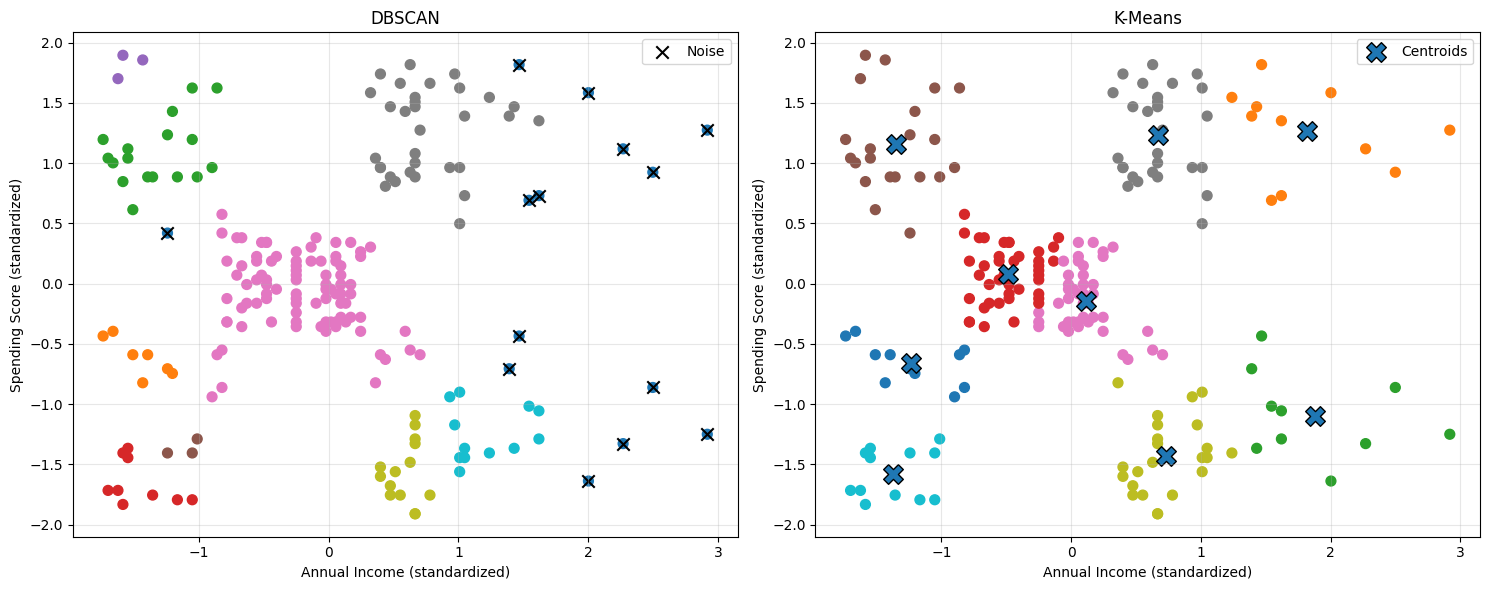

In [20]:


from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ------------------------------------------
# DBSCAN
# ------------------------------------------

dbscan = DBSCAN(
    eps=0.30,
    min_samples=3
)

dbscan_labels = dbscan.fit_predict(X_scaled)

dbscan_clusters = len(
    set(dbscan_labels)
) - (1 if -1 in dbscan_labels else 0)

dbscan_noise = list(dbscan_labels).count(-1)

print("DBSCAN")
print("Number of clusters:", dbscan_clusters)
print("Number of noise points:", dbscan_noise)


# ------------------------------------------
# K-Means
# ------------------------------------------

# Use exactly the same number of clusters
kmeans = KMeans(
    n_clusters=dbscan_clusters,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("\nK-Means")
print("Number of clusters:", dbscan_clusters)


# ------------------------------------------
# Plot both algorithms side-by-side
# ------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# DBSCAN plot
axes[0].scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=dbscan_labels,
    cmap="tab10",
    s=50
)

# Highlight DBSCAN noise
noise_mask = dbscan_labels == -1

axes[0].scatter(
    X_scaled[noise_mask, 0],
    X_scaled[noise_mask, 1],
    c="black",
    marker="x",
    s=80,
    label="Noise"
)

axes[0].set_title("DBSCAN")
axes[0].set_xlabel("Annual Income (standardized)")
axes[0].set_ylabel("Spending Score (standardized)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# K-Means plot
axes[1].scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=kmeans_labels,
    cmap="tab10",
    s=50
)

# Plot K-Means centroids
axes[1].scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    edgecolor="black",
    label="Centroids"
)

axes[1].set_title("K-Means")
axes[1].set_xlabel("Annual Income (standardized)")
axes[1].set_ylabel("Spending Score (standardized)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Number of clusters: 2
Number of noise points: 4

Indices of noise/outlier points:
[97, 178, 220, 223]


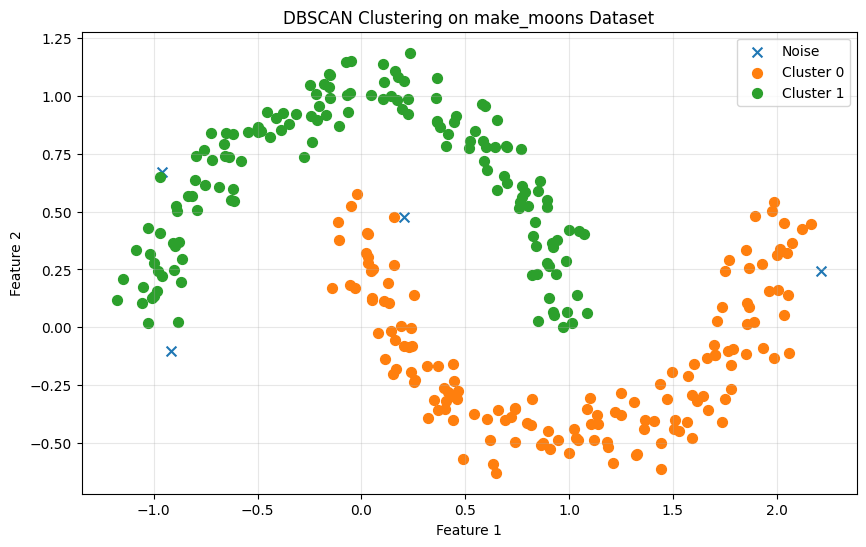

In [21]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

# Create moon-shaped dataset
X_moons, y_moons = make_moons(
    n_samples=300,
    noise=0.08,
    random_state=42
)

# Apply DBSCAN
dbscan_moons = DBSCAN(
    eps=0.15,
    min_samples=5
)

moon_labels = dbscan_moons.fit_predict(X_moons)

# Find noise points
noise_indices = np.where(moon_labels == -1)[0]

# Number of clusters
moon_clusters = len(
    set(moon_labels)
) - (1 if -1 in moon_labels else 0)

# Print results
print("Number of clusters:", moon_clusters)
print("Number of noise points:", len(noise_indices))

print("\nIndices of noise/outlier points:")
print(noise_indices.tolist())


# ------------------------------------------
# Visualization
# ------------------------------------------

plt.figure(figsize=(10, 6))

unique_labels = sorted(set(moon_labels))

for label in unique_labels:

    if label == -1:
        marker = "x"
        label_name = "Noise"
    else:
        marker = "o"
        label_name = f"Cluster {label}"

    points = X_moons[moon_labels == label]

    plt.scatter(
        points[:, 0],
        points[:, 1],
        marker=marker,
        s=50,
        label=label_name
    )

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering on make_moons Dataset")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()